# Constraint-Aware Warehouse Shelf Optimization using AI

In [1]:
#Imports
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

In [2]:
#Configuration

NUM_ITEMS = 50
NUM_ORDERS = 1000
GRID_SIZE = 10

SA_ITERS = 10000
INITIAL_TEMP = 1000
COOLING_RATE = 0.995
T_MIN = 1e-3
GUIDED_RATIO = 0.7

COST_SAMPLE_SIZE = 200
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [3]:
#Data generation

def generate_data(num_items, num_orders):
    # relies on global seed

    items = list(range(num_items))

    item_type = {
        i: random.choice(["frozen", "fragile", "normal"])
        for i in items
    }

    # demand clusters
    groups = [random.sample(items, 5) for _ in range(3)]

    orders = []
    for _ in range(num_orders):
        if random.random() < 0.7:
            group = random.choice(groups)
            order = random.sample(group, random.randint(2, 4))
        else:
            order = random.sample(items, random.randint(2, 6))
        orders.append(order)

    return items, item_type, orders


items, item_type, orders = generate_data(NUM_ITEMS, NUM_ORDERS)

In [4]:
#Co-occurance matrix
def build_cooccurrence(orders, num_items):
    matrix = np.zeros((num_items, num_items))

    for order in orders:
        for i in range(len(order)):
            for j in range(i + 1, len(order)):
                a, b = order[i], order[j]
                matrix[a][b] += 1
                matrix[b][a] += 1

    return matrix


co_matrix = build_cooccurrence(orders, NUM_ITEMS)

In [5]:
# Precompute top co-occurrence pairs (ONLY ONCE)
pairs = []

for i in range(NUM_ITEMS):
    for j in range(i + 1, NUM_ITEMS):
        if co_matrix[i][j] > 0:
            pairs.append((co_matrix[i][j], i, j))

pairs.sort(reverse=True)

# Take top 20 important pairs
top_pairs = [(i, j) for _, i, j in pairs[:20]]

### Warehouse grid and zones

In [6]:
def create_warehouse(grid_size):
    return [(i, j) for i in range(grid_size) for j in range(grid_size)]


def assign_zones(grid):
    zone_sorted = {"frozen": [], "fragile": [], "normal": []}

    for x, y in grid:
        if x < GRID_SIZE // 3:
            zone_sorted["frozen"].append((x, y))
        elif x < 2 * GRID_SIZE // 3:
            zone_sorted["fragile"].append((x, y))
        else:
            zone_sorted["normal"].append((x, y))

    return zone_sorted


grid = create_warehouse(GRID_SIZE)
zone_sorted = assign_zones(grid)

In [7]:
#Creates Initial Layout
def create_initial_layout(items, item_type, zone_sorted):
    layout = {}
    zone_copy = {k: deque(v) for k, v in zone_sorted.items()}

    for item in items:
        layout[item] = zone_copy[item_type[item]].popleft()

    return layout


layout = create_initial_layout(items, item_type, zone_sorted)

In [8]:
#Distance Function

def smart_distance(p1, p2):
    dx = abs(p1[0] - p2[0])
    dy = abs(p1[1] - p2[1])

    vertical = dx * 0.5 if dx <= 1 else dx * 3
    return vertical + dy

#Cost Function
def order_distance(order, layout):
    current = (0, 0)
    dist = 0

    for item in order:
        next_pos = layout[item]
        dist += smart_distance(current, next_pos)
        current = next_pos

    dist += smart_distance(current, (0, 0))
    return dist

In [9]:
#Co-occurance penalty
def co_occurrence_penalty(layout, co_matrix):
    penalty = 0
    n = len(co_matrix)

    for i in range(n):
        for j in range(i + 1, n):
            if co_matrix[i][j] > 0:
                d = smart_distance(layout[i], layout[j])
                penalty += co_matrix[i][j] * d

    return penalty

In [10]:
def compute_objective_weights(layout, orders, co_matrix):
    subset = orders[:COST_SAMPLE_SIZE]

    travel = sum(order_distance(o, layout) for o in subset)
    co_pen = co_occurrence_penalty(layout, co_matrix)

    alpha = travel / (co_pen + 1e-8)

    print("\n[Scaling]")
    print("Travel:", travel)
    print("Co-penalty:", co_pen)
    print("Alpha:", alpha)

    return alpha


alpha = compute_objective_weights(layout, orders, co_matrix)


[Scaling]
Travel: 9327.5
Co-penalty: 49401.5
Alpha: 0.18881005637476822


In [11]:
def total_cost(layout, orders):
    subset = orders[:COST_SAMPLE_SIZE]

    travel_cost = sum(order_distance(o, layout) for o in subset)
    co_penalty = co_occurrence_penalty(layout, co_matrix)

    return travel_cost + alpha * co_penalty

In [12]:
# Random baseline
random_layout_map = {item: pos for item, pos in zip(items, random.sample(grid, len(items)))}
random_cost = total_cost(random_layout_map, orders)

In [13]:
def is_valid_swap(a, b, layout, item_type, zone_sorted):
    pos_a = layout[a]
    pos_b = layout[b]

    return (
        pos_b in zone_sorted[item_type[a]] and
        pos_a in zone_sorted[item_type[b]]
    )

In [14]:
def optimize(layout, orders, iters, cooling_rate):
    current_layout = layout.copy()
    best_layout = layout.copy()

    current_cost = total_cost(current_layout, orders)
    best_cost = current_cost

    T = INITIAL_TEMP
    items = list(layout.keys())

    cost_history = []

    for _ in range(iters):

        max_attempts = 100
        found = False

        for _ in range(max_attempts):

            # guided + random mix
            if random.random() < GUIDED_RATIO:
                a, b = random.choice(top_pairs)
            else:
                a, b = random.sample(items, 2)

            if is_valid_swap(a, b, current_layout, item_type, zone_sorted):
                found = True
                break

        if not found:
            cost_history.append(best_cost)
            continue

        current_layout[a], current_layout[b] = current_layout[b], current_layout[a]

        new_cost = total_cost(current_layout, orders)
        delta = new_cost - current_cost

        if delta < 0 or random.random() < math.exp(-delta / max(T, T_MIN)):
            current_cost = new_cost
        else:
            current_layout[a], current_layout[b] = current_layout[b], current_layout[a]

        if current_cost < best_cost:
            best_layout = current_layout.copy()
            best_cost = current_cost

        T = max(T * cooling_rate, T_MIN)
        cost_history.append(best_cost)

    return best_layout, best_cost, cost_history

### Simulated Annealing Optimization

Simulated Annealing is a probabilistic optimization algorithm that allows occasional acceptance of worse solutions to escape local minima.

Key components:
- Temperature controls exploration (high → explore, low → exploit)
- Guided swaps use co-occurrence to prioritize meaningful moves
- Random swaps maintain exploration to avoid getting stuck
- Constraint checks ensure valid warehouse placement

This combination enables efficient global optimization of warehouse layout.

In [15]:
def greedy_optimize(layout, orders, iters=10000):
    current_layout = layout.copy()
    current_cost = total_cost(current_layout, orders)

    best_layout = current_layout.copy()
    best_cost = current_cost

    items = list(layout.keys())

    cost_history = []

    for _ in range(iters):

        a, b = random.sample(items, 2)

        if not is_valid_swap(a, b, current_layout, item_type, zone_sorted):
            cost_history.append(best_cost)
            continue

        # swap
        current_layout[a], current_layout[b] = current_layout[b], current_layout[a]

        new_cost = total_cost(current_layout, orders)

        if new_cost < current_cost:
            current_cost = new_cost

            if current_cost < best_cost:
                best_layout = current_layout.copy()
                best_cost = current_cost
        else:
            # revert
            current_layout[a], current_layout[b] = current_layout[b], current_layout[a]

        cost_history.append(best_cost)

    return best_layout, best_cost, cost_history

In [16]:
greedy_layout, greedy_cost, greedy_history = greedy_optimize(layout, orders, iters=SA_ITERS)

In [17]:
initial_cost = total_cost(layout, orders)

best_layout, best_cost, cost_history = optimize(layout, orders, SA_ITERS, COOLING_RATE)

improvement = ((initial_cost - best_cost) / initial_cost) * 100

print(f"Improvement: {improvement:.2f}%")

Improvement: 25.27%


In [18]:
improvement = ((initial_cost - best_cost) / initial_cost) * 100

results_df = pd.DataFrame({
    "Algorithm": ["Random", "Initial", "Greedy", "Simulated Annealing"],
    "Cost": [random_cost, initial_cost, greedy_cost, best_cost]
})

print("\n=== FINAL RESULTS ===")
print(results_df.round(2))


=== FINAL RESULTS ===
             Algorithm      Cost
0               Random  23528.09
1              Initial  18655.00
2               Greedy  13847.69
3  Simulated Annealing  13940.43


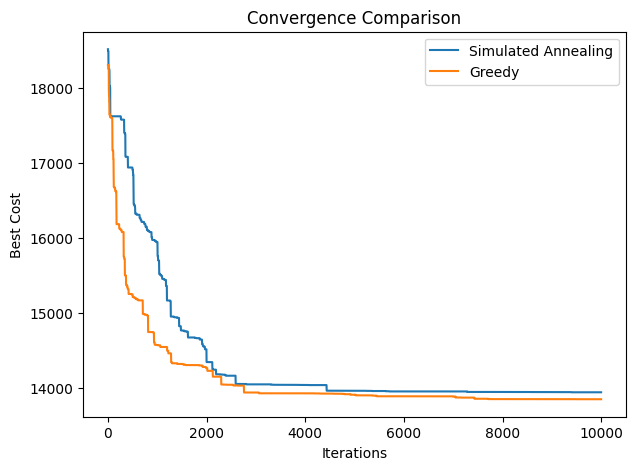

In [19]:
# Convergence Plot
plt.figure(figsize=(7,5))

plt.plot(cost_history, label="Simulated Annealing")
plt.plot(greedy_history, label="Greedy")

plt.xlabel("Iterations")
plt.ylabel("Best Cost")
plt.title("Convergence Comparison")

plt.legend()
plt.show()

In [20]:
ratios = [0.5, 0.7, 0.9]
ratio_results = []

for r in ratios:
    GUIDED_RATIO = r
    _, cost, _ = optimize(layout, orders, SA_ITERS, COOLING_RATE)
    ratio_results.append((r, cost))

ratio_df = pd.DataFrame(ratio_results, columns=["Ratio", "Cost"])
print(ratio_df)

   Ratio          Cost
0    0.5  13768.359863
1    0.7  14031.715712
2    0.9  14562.719907


In [21]:
GUIDED_RATIO = 0.7

In [22]:
import time

cooling_rates = [0.99, 0.995, 0.999]
results = []

for rate in cooling_rates:
    start = time.time()

    _, cost, _ = optimize(layout, orders, SA_ITERS, rate)

    t = time.time() - start

    results.append((rate, cost, t))

In [23]:
hp_df = pd.DataFrame(results, columns=["Cooling Rate", "Cost", "Time"])

print("\n=== Hyperparameter Results ===")
print(hp_df.round(4))


=== Hyperparameter Results ===
   Cooling Rate        Cost     Time
0         0.990  13939.5385  15.5794
1         0.995  13963.3812  15.1001
2         0.999  14171.1012  15.3510


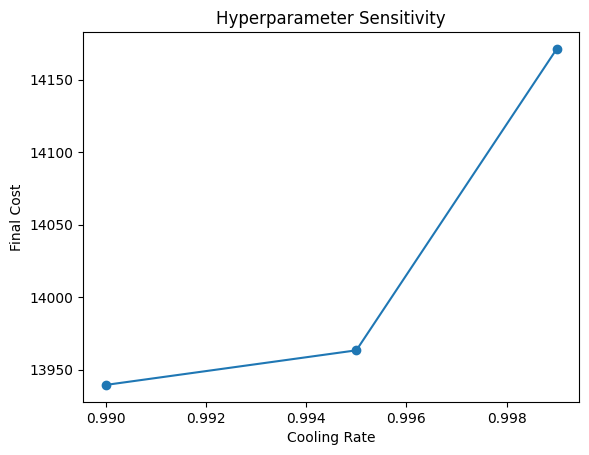

In [24]:
plt.plot(hp_df["Cooling Rate"], hp_df["Cost"], marker='o')
plt.xlabel("Cooling Rate")
plt.ylabel("Final Cost")
plt.title("Hyperparameter Sensitivity")
plt.show()

### Plots

In [25]:
#Zone-Layout plot
def plot_zone_layout_comparison(layout1, layout2, item_type):

    def create_grid(layout):
        grid = [["" for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
        type_grid = np.zeros((GRID_SIZE, GRID_SIZE))

        mapping = {"frozen": 1, "fragile": 2, "normal": 3}

        for item, (x, y) in layout.items():
            grid[x][y] = str(item)
            type_grid[x][y] = mapping[item_type[item]]

        return grid, type_grid

    grid1, type1 = create_grid(layout1)
    grid2, type2 = create_grid(layout2)

    #  CUSTOM COLORS (BEST CHOICE)
    from matplotlib.colors import ListedColormap

    cmap = ListedColormap(["#5DADE2", "#F7DC6F", "#58D68D"])

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    axs[0].imshow(type1, cmap=cmap, vmin=1, vmax=3)
    axs[0].set_title("Initial Layout")

    axs[1].imshow(type2, cmap=cmap, vmin=1, vmax=3)
    axs[1].set_title("Optimized Layout")

    # numbers
    for ax, grid in zip(axs, [grid1, grid2]):
        for i in range(GRID_SIZE):
            for j in range(GRID_SIZE):
                if grid[i][j] != "":
                    ax.text(j, i, grid[i][j],
                            ha='center', va='center', fontsize=6, color='black')

    #  CLEAN LEGEND
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor="#5DADE2", label='Frozen'),
        Patch(facecolor="#F7DC6F", label='Fragile'),
        Patch(facecolor="#58D68D", label='Normal')
]

    fig.legend(handles=legend_elements, loc='upper center', ncol=3)

    plt.tight_layout()
    plt.show()

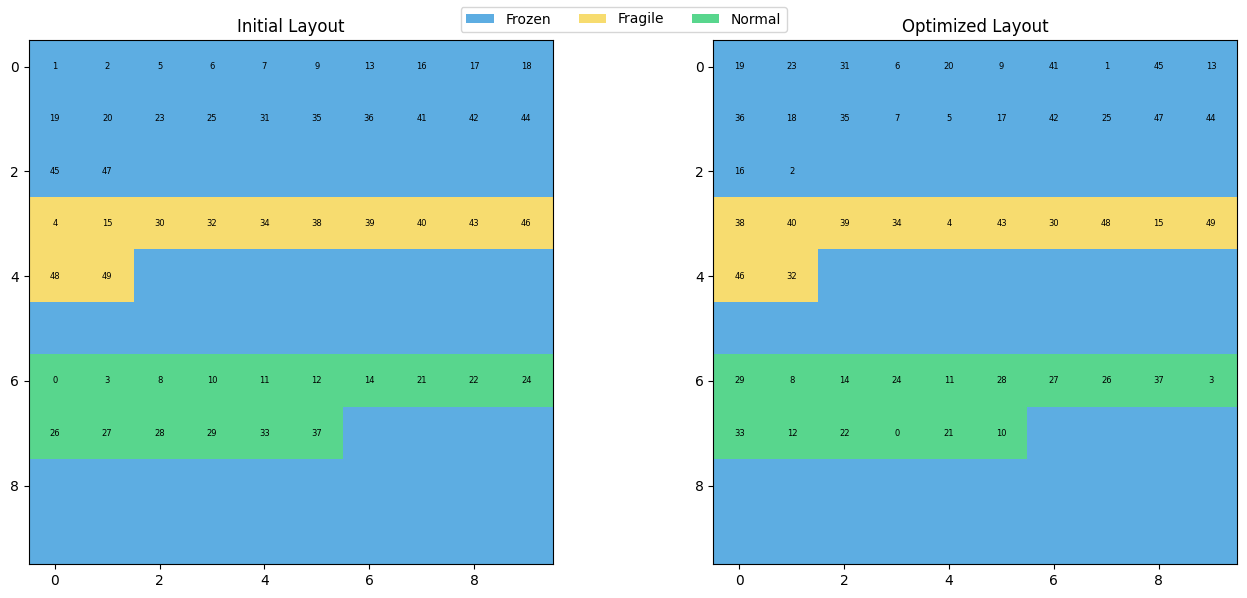

In [26]:
plot_zone_layout_comparison(layout, best_layout, item_type)

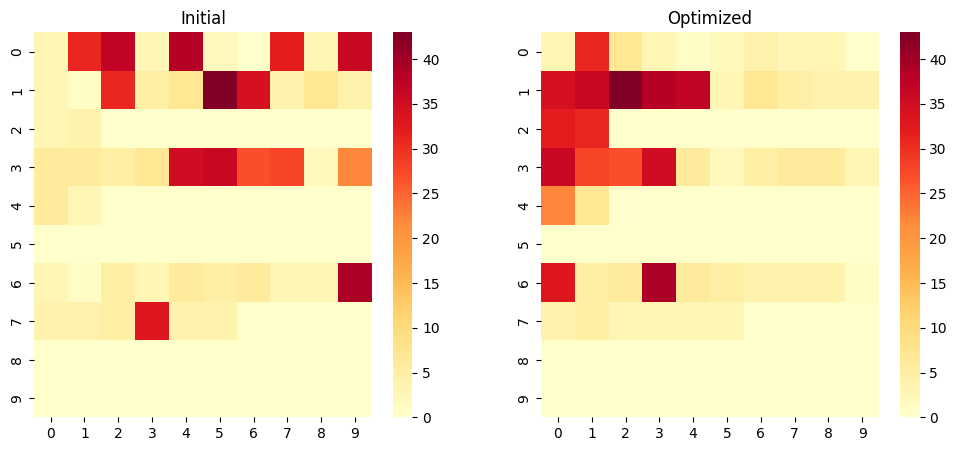

In [27]:
#Heatmaps Comparision
def compute_visits(layout, orders):
    visit_map = np.zeros((GRID_SIZE, GRID_SIZE))

    for order in orders[:COST_SAMPLE_SIZE]:
        for item in order:
            x, y = layout[item]
            visit_map[x][y] += 1

    return visit_map


init_v = compute_visits(layout, orders)
opt_v = compute_visits(best_layout, orders)

fig, axs = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(init_v, ax=axs[0], cmap="YlOrRd")
axs[0].set_title("Initial")

sns.heatmap(opt_v, ax=axs[1], cmap="YlOrRd")
axs[1].set_title("Optimized")

plt.show()

In [28]:
display_pairs = []

for i in range(NUM_ITEMS):
    for j in range(i + 1, NUM_ITEMS):
        display_pairs.append((co_matrix[i][j], i, j))

display_pairs.sort(reverse=True)

print("\nTop 10 Co-occurring Pairs:")

for val, i, j in display_pairs[:10]:
    d = smart_distance(best_layout[i], best_layout[j])
    print(f"Items {i}-{j} | Co-occurrence: {val:.0f} | Distance: {d:.2f}")


Top 10 Co-occurring Pairs:
Items 7-35 | Co-occurrence: 98 | Distance: 1.00
Items 5-7 | Co-occurrence: 96 | Distance: 1.00
Items 18-40 | Co-occurrence: 93 | Distance: 6.00
Items 5-35 | Co-occurrence: 93 | Distance: 2.00
Items 18-23 | Co-occurrence: 92 | Distance: 0.50
Items 24-35 | Co-occurrence: 89 | Distance: 16.00
Items 18-36 | Co-occurrence: 85 | Distance: 1.00
Items 7-24 | Co-occurrence: 84 | Distance: 15.00
Items 18-39 | Co-occurrence: 83 | Distance: 7.00
Items 39-40 | Co-occurrence: 82 | Distance: 1.00


### Summary

In [29]:
#Defining
def avg_order_cost(layout):
    subset = orders[:COST_SAMPLE_SIZE]
    return np.mean([order_distance(o, layout) for o in subset])


def avg_co_distance(layout):
    total_weighted_dist = 0
    total_weight = 0

    for i in range(NUM_ITEMS):
        for j in range(i + 1, NUM_ITEMS):
            weight = co_matrix[i][j]

            if weight > 0:
                dist = smart_distance(layout[i], layout[j])

                total_weighted_dist += weight * dist
                total_weight += weight

    return total_weighted_dist / (total_weight + 1e-8)

In [30]:
print("\n=== FINAL SUMMARY ===")

print(f"Initial Cost: {initial_cost:.0f}")
print(f"Greedy Cost: {greedy_cost:.0f}")
print(f"SA Cost: {best_cost:.0f}")

improvement_sa = ((initial_cost - best_cost) / initial_cost) * 100
improvement_greedy = ((initial_cost - greedy_cost) / initial_cost) * 100

print(f"\nImprovement (Greedy): {improvement_greedy:.2f}%")
print(f"Improvement (SA): {improvement_sa:.2f}%")

# Metrics
print(f"\nAvg order cost (initial): {avg_order_cost(layout):.2f}")
print(f"Avg order cost (greedy): {avg_order_cost(greedy_layout):.2f}")
print(f"Avg order cost (optimized): {avg_order_cost(best_layout):.2f}")

print(f"\nAvg co-occurrence distance (initial): {avg_co_distance(layout):.2f}")
print(f"Avg co-occurrence distance (greedy): {avg_co_distance(greedy_layout):.2f}")
print(f"Avg co-occurrence distance (optimized): {avg_co_distance(best_layout):.2f}")


=== FINAL SUMMARY ===
Initial Cost: 18655
Greedy Cost: 13848
SA Cost: 13940

Improvement (Greedy): 25.77%
Improvement (SA): 25.27%

Avg order cost (initial): 46.64
Avg order cost (greedy): 34.31
Avg order cost (optimized): 34.17

Avg co-occurrence distance (initial): 11.03
Avg co-occurrence distance (greedy): 8.26
Avg co-occurrence distance (optimized): 8.40
